In [45]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [46]:
X = torch.linspace(0.1, 10.5, 50)
X1 = X[::2]
X2 = X[1::2]
X = torch.stack((X1.squeeze(0), X2.squeeze(0)), dim=1)
X, X1, X2

(tensor([[ 0.1000,  0.3122],
         [ 0.5245,  0.7367],
         [ 0.9490,  1.1612],
         [ 1.3735,  1.5857],
         [ 1.7980,  2.0102],
         [ 2.2224,  2.4347],
         [ 2.6469,  2.8592],
         [ 3.0714,  3.2837],
         [ 3.4959,  3.7082],
         [ 3.9204,  4.1327],
         [ 4.3449,  4.5571],
         [ 4.7694,  4.9816],
         [ 5.1939,  5.4061],
         [ 5.6184,  5.8306],
         [ 6.0429,  6.2551],
         [ 6.4673,  6.6796],
         [ 6.8918,  7.1041],
         [ 7.3163,  7.5286],
         [ 7.7408,  7.9531],
         [ 8.1653,  8.3776],
         [ 8.5898,  8.8020],
         [ 9.0143,  9.2265],
         [ 9.4388,  9.6510],
         [ 9.8633, 10.0755],
         [10.2878, 10.5000]]),
 tensor([ 0.1000,  0.5245,  0.9490,  1.3735,  1.7980,  2.2224,  2.6469,  3.0714,
          3.4959,  3.9204,  4.3449,  4.7694,  5.1939,  5.6184,  6.0429,  6.4673,
          6.8918,  7.3163,  7.7408,  8.1653,  8.5898,  9.0143,  9.4388,  9.8633,
         10.2878]),
 tensor([ 

In [47]:
y = (X1 * (-0.23)) + (X2 * 0.065) + 0.87
y

tensor([ 0.8673,  0.7973,  0.7272,  0.6572,  0.5871,  0.5171,  0.4471,  0.3770,
         0.3070,  0.2369,  0.1669,  0.0968,  0.0268, -0.0432, -0.1133, -0.1833,
        -0.2534, -0.3234, -0.3934, -0.4635, -0.5335, -0.6036, -0.6736, -0.7436,
        -0.8137])

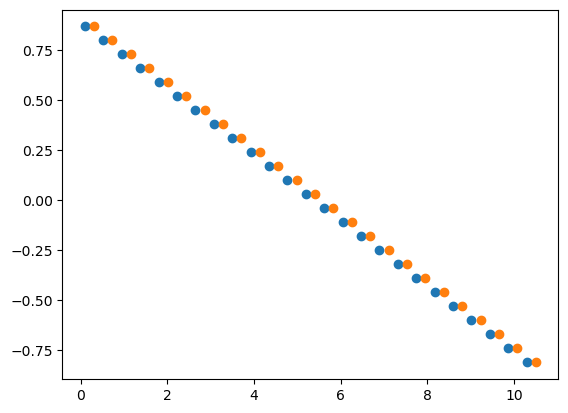

In [48]:
plt.scatter(X1, y)
plt.scatter(X2, y)

In [49]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layers(x)

In [50]:
m1 = LinearModel()
m1.state_dict()

OrderedDict([('layers.0.weight', tensor([[-0.7040, -0.4189]])),
             ('layers.0.bias', tensor([-0.5152]))])

In [78]:
def print_graph(fn, val, indent=0):
    if fn is None:
        return
    print(" " * indent, f"{fn} | {val}")
    for next_fn, val in fn.next_functions:
        print_graph(next_fn, val,  indent + 2)

In [79]:
print_graph(res.grad_fn, res)

 <ReluBackward0 object at 0x0000025E8A11E830> | tensor([0.], grad_fn=<ReluBackward0>)
   <ViewBackward0 object at 0x0000025E8A11E9B0> | 0
     <AddmmBackward0 object at 0x0000025E8A11EE00> | 0
       <AccumulateGrad object at 0x0000025E8A11FFA0> | 0
       <TBackward0 object at 0x0000025E8ACF9F30> | 0
         <AccumulateGrad object at 0x0000025E8ACC9000> | 0


In [85]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(params=m1.parameters())

In [90]:
epochs = 100
for epoch in range(epochs):
    m1.train()
    optimizer.zero_grad()
    pred = m1(X)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()

    print_graph(pred.grad_fn, 0)

 <ReluBackward0 object at 0x0000025E8DDFD210> | 0
   <AddmmBackward0 object at 0x0000025E8DDFC070> | 0
     <AccumulateGrad object at 0x0000025E8DDFD0F0> | 0
     <TBackward0 object at 0x0000025E8DDFD4E0> | 0
       <AccumulateGrad object at 0x0000025E8DDFD0C0> | 0
 <ReluBackward0 object at 0x0000025E8A2D9F00> | 0
   <AddmmBackward0 object at 0x0000025E8DBCEBC0> | 0
     <AccumulateGrad object at 0x0000025E8DDFD0F0> | 0
     <TBackward0 object at 0x0000025E8DDFD4E0> | 0
       <AccumulateGrad object at 0x0000025E8DDFCEB0> | 0
 <ReluBackward0 object at 0x0000025E8A2D9F00> | 0
   <AddmmBackward0 object at 0x0000025E8DBCEBC0> | 0
     <AccumulateGrad object at 0x0000025E8DDFD0F0> | 0
     <TBackward0 object at 0x0000025E8DDFD4E0> | 0
       <AccumulateGrad object at 0x0000025E8DDFD0C0> | 0
 <ReluBackward0 object at 0x0000025E8A2D9F00> | 0
   <AddmmBackward0 object at 0x0000025E8DBCEBC0> | 0
     <AccumulateGrad object at 0x0000025E8DDFD0F0> | 0
     <TBackward0 object at 0x0000025E8DDFD4E

C:\Users\shiva\anaconda3\envs\DeepLearning\lib\site-packages\torch\nn\modules\loss.py:128: UserWarning: Using a target size (torch.Size([25])) that is different to the input size (torch.Size([25, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
